#### Teoría de los Circuitos 2
# Trabajo semanal 4
#### Leandro Robledo

A partir de la siguiente plantilla, sabiendo que en banda de paso la respuesta es Chebyshev:
![Plantilla](Plantilla.PNG)
$f_0=22kHz; f_{s1}=17kHz; f_{s2}=36kHz;  \quad$ 
$ Q=5 \quad siendo \quad \omega1.\omega2=\omega_0^2 \quad \omega1-\omega2=\omega_0/Q$  
   
  
1. Obtener la [plantilla de atenuación normalizada en frecuencia.](#plantiila_lp)  Indicar los valores de $\alpha_{min}$
 y de $\alpha_{max}$ 

2. Obtener la función [transferencia normalizada del prototipo pasa bajo](#trans_LP) que satisfaga el requerimiento del filtro pasa banda.

3. Aplicar el núcleo de [transformación pasa banda](#Trans_PB) y obtener la transferencia. Factorizar convenientemente para expresar en SOS.

4. Realizar la [simulación numérica en python](#simPY). Graficar la respuesta en frecuencia del filtro pasa banda total, y las de las SOS. 

Bonus


+10 💎 [Simulación Circuital del filtro pasa banda](simuPB) implementado mediante secciones pasivas separadas por seguidores de tensión activos. 

+10 💎 Dado el pasa bajo hallado en 2)  aplicar el núcleo de [transformación pasa altos](#Trans_HP) y obtener la transferencia.

+10 💎 Dado el pasa bajo hallado en 2) , implementarlo con [pasivos y aplicar la transformación de Bruton](#FDNR). Obtener el valor numérico de D del FDNR siendo 


#### 1.
![Plantilla_lp](plantilla_LP.jpeg) <a id="plantiila_"></a>

#### 2.
![Transferencia_LP](T_LP.jpeg)<a id="trans_LP"></a>

Con cheby1ap
second order sistem omegayq con zpk


<IPython.core.display.Math object>

<IPython.core.display.Math object>

numerador [0.71569379]
den [1.         1.25291297 1.53489546 0.71569379]
con poliniomio tipeado second order sistem omegayq


<IPython.core.display.Math object>

tranferencia completa


<IPython.core.display.Math object>

numerador [0.71569379]
den [1.         1.25291297 1.53489546 0.71569379]
Esp^2 0.34931140018894796


'esto es para desnormalizar a otra frec\nprint ("lpl:")\nnum, den = sig.lp2lp(num, den, eps**(-1/this_order))\nthis_sos = tf2sos_analog(num, den)\nprint ("second order sistem omegayq con zpk")\npretty_print_SOS(this_sos, mode=\'omegayq\')\npretty_print_lti(num,den)\nprint ("numerador", num)\nprint ("den", den)\n'

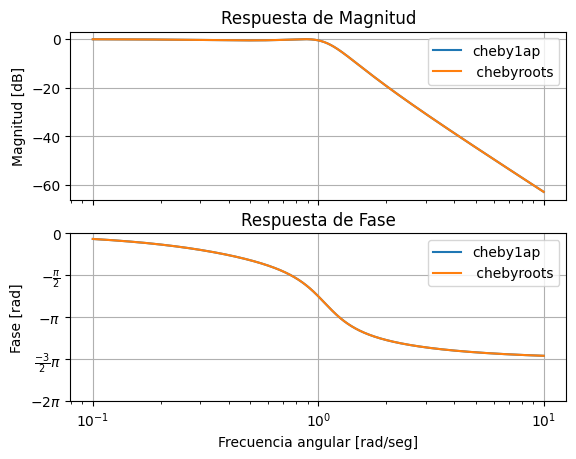

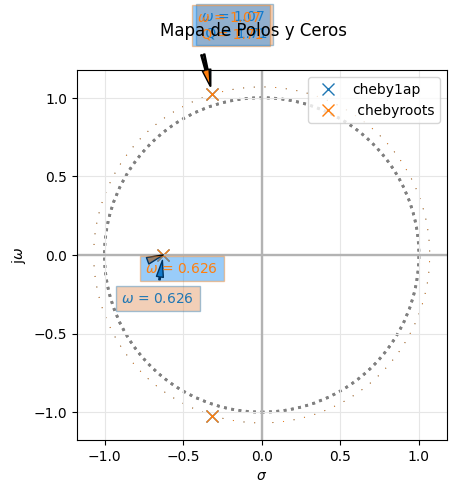

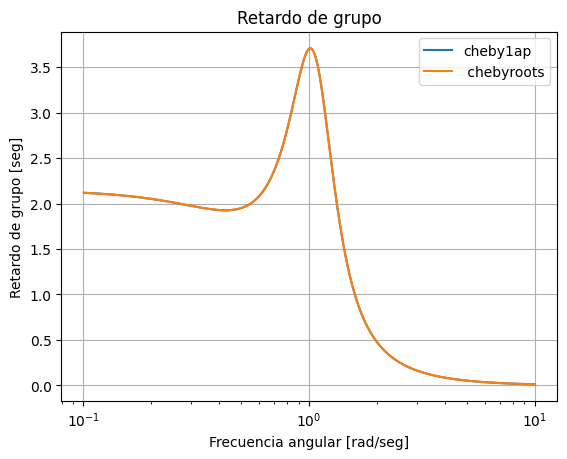

In [25]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Wed Jun 10 19:11:35 2026

@author: lrobledo
"""
# Librerías externas NumPy, SciPy y Matplotlib
from scipy.signal import TransferFunction
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sig

# Librería de TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot

# Ahora importamos las funciones de PyTC2

from pytc2.sistemas_lineales import analyze_sys, pretty_print_bicuad_omegayq, tf2sos_analog, pretty_print_SOS, pretty_print_lti

this_order = 3
this_ripple = 0.5
eps = np.sqrt( 10**(this_ripple/10) - 1 )


den = np.array([1, 0, 24/16, 0, 9/16, 0, -1/(eps**2*16)])       # s⁶+24/16s⁴+9/16s²+1/e²16
#denominador de cheby ya expandido, viene de tener 1+eps^2*Cn^2, siendo Cn=4w^3-3w
np.roots(den)
cheby_roots = np.roots(den)
cheby_roots = cheby_roots[ np.real(cheby_roots) < 0 ]
cheby_roots
z=[]
num, den = sig.zpk2tf(z,cheby_roots,k)
mi_tf = sig.TransferFunction(num,den)
analyze_sys( mi_tf ," chebyroots")

this_sos = tf2sos_analog(num, den)
print ("con poliniomio tipeado second order sistem omegayq")
pretty_print_SOS(this_sos, mode='omegayq')
print ("tranferencia completa")
pretty_print_lti(num,den)
print ("numerador", num)
print ("den", den)

"""
hecho automatico con cheb1ap
"""
z,p,k = sig.cheb1ap(this_order, this_ripple )
num, den = sig.zpk2tf(z,p,k)
this_sos = tf2sos_analog(num, den)
print("Con cheby1ap")
print ("second order sistem omegayq con zpk")
pretty_print_SOS(this_sos, mode='omegayq')
pretty_print_lti(num,den)
print ("numerador", num)
print ("den", den)
mi_tf = sig.TransferFunction(num,den)
analyze_sys( mi_tf, "cheby1ap" )



#### 3.
![Transferencia_PB](T_PB.jpeg)<a id="Trans_PB"></a>

#### 4.<a id="Trans_PB"></a>

(3,
 <Axes: title={'center': 'Retardo de grupo'}, xlabel='Frecuencia angular [rad/seg]', ylabel='Retardo de grupo [seg]'>)

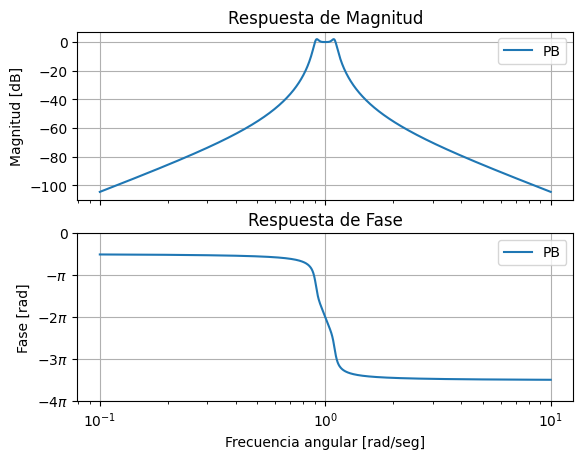

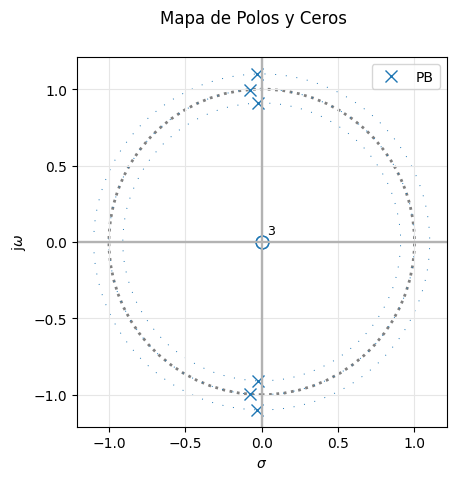

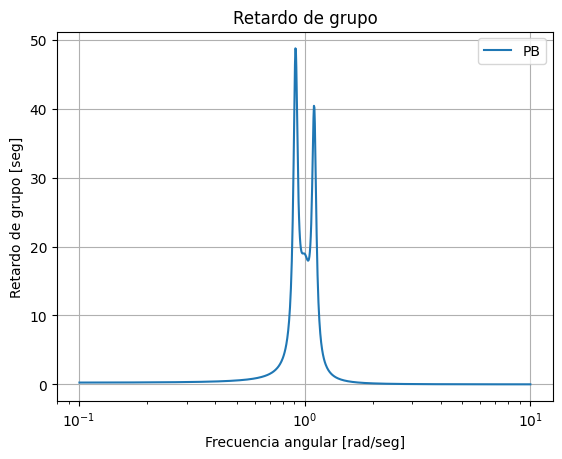

In [27]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Wed Jun 10 19:11:35 2026

@author: lrobledo
"""
# Librerías externas NumPy, SciPy y Matplotlib
from scipy.signal import TransferFunction
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sig

# Librería de TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot

# Ahora importamos las funciones de PyTC2

from pytc2.sistemas_lineales import analyze_sys, pretty_print_bicuad_omegayq, tf2sos_analog, pretty_print_SOS, pretty_print_lti

Q=5

num = [(0.7157/Q**3),0,0,0]   # 2.049/Q s^3 
den = [1, 1.253/Q, (3 + 1.353/Q**2), ((2*1.253)/Q + 0.7157/Q**3), (3+1.353/Q**2), (1.253/Q), 1]       
my_tf = TransferFunction(num, den)

plt.close('all')
my_tf = TransferFunction(num, den)
bodePlot(my_tf, fig_id=1, filter_description = 'PB')
pzmap(my_tf, fig_id=2, filter_description = 'PB')
GroupDelay(my_tf, fig_id=3, filter_description = 'PB')



<IPython.core.display.Math object>

[[1,
  array([<Axes: title={'center': 'Respuesta de Magnitud'}, ylabel='Magnitud [dB]'>,
         <Axes: title={'center': 'Respuesta de Fase'}, xlabel='Frecuencia angular [rad/seg]', ylabel='Fase [rad]'>],
        dtype=object)],
 [2, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>],
 [3, []],
 [4,
  <Axes: title={'center': 'Retardo de grupo'}, xlabel='Frecuencia angular [rad/seg]', ylabel='Retardo de grupo [seg]'>]]

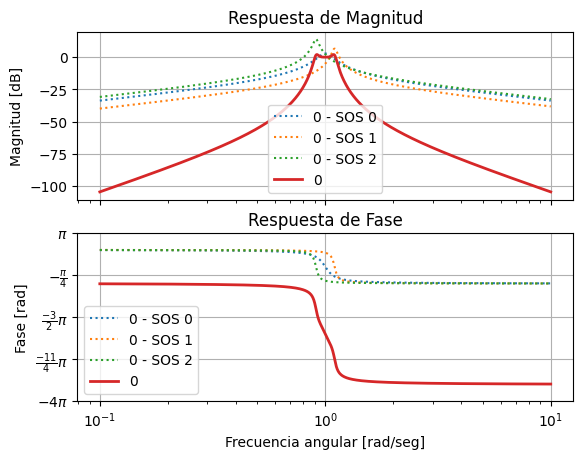

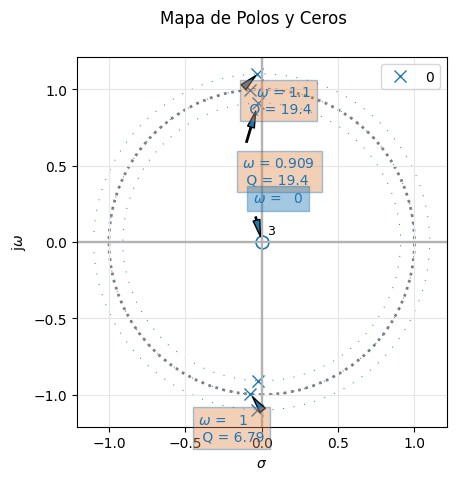

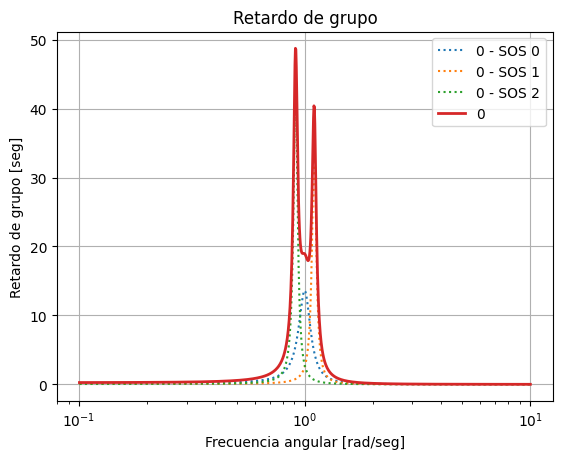

In [30]:
this_sos = tf2sos_analog(num, den)
pretty_print_SOS(this_sos, mode='omegayq')
analyze_sys(this_sos)

#### Bonus.1.
![Circuito_simulacion_PB](Circ_PasaBanda.PNG)<a id="simuPB"></a>
![Simulacion_PB](bode_PasaBanda.PNG)
![Calculos_PB](Calculos_PB.jpeg)


#### Bonus.1.
![Transformacion_Pasa_Altos](Trans_HP.jpeg)<a id="Trans_HP"></a>


(3,
 <Axes: title={'center': 'Retardo de grupo'}, xlabel='Frecuencia angular [rad/seg]', ylabel='Retardo de grupo [seg]'>)

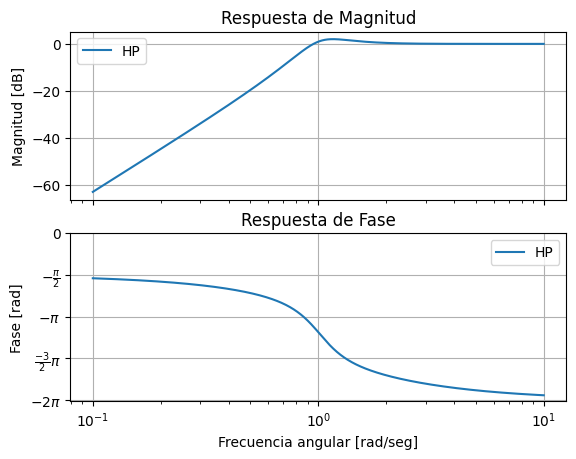

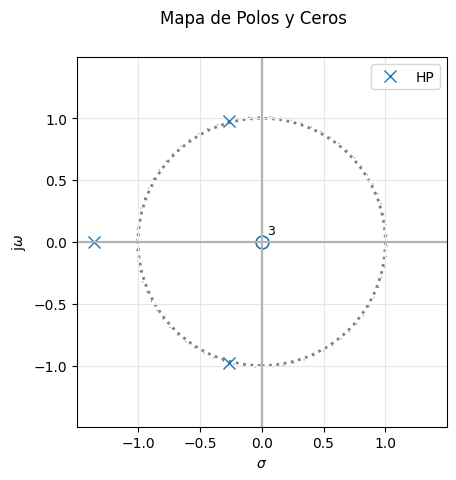

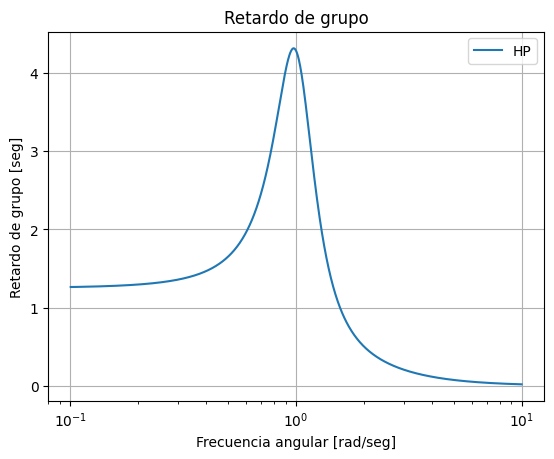

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Wed Jun 10 19:11:35 2026

@author: lrobledo
"""
# Librerías externas NumPy, SciPy y Matplotlib
from scipy.signal import TransferFunction
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sig

# Librería de TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot

# Ahora importamos las funciones de PyTC2

from pytc2.sistemas_lineales import analyze_sys, pretty_print_bicuad_omegayq, tf2sos_analog, pretty_print_SOS, pretty_print_lti

numHp = [(0.7157),0,0,0]   
denHp = [0.7157, 1.353, 1.253, 1]       
my_tf = TransferFunction(numHp, denHp)

plt.close('all')
my_tf = TransferFunction(numHp, denHp)
bodePlot(my_tf, fig_id=1, filter_description = 'HP')
pzmap(my_tf, fig_id=2, filter_description = 'HP')
GroupDelay(my_tf, fig_id=3, filter_description = 'HP')



numerador: [0.7157, 0, 0, 0]
denominador: [0.7157, 1.353, 1.253, 1]


<IPython.core.display.Math object>

[[1,
  array([<Axes: title={'center': 'Respuesta de Magnitud'}, ylabel='Magnitud [dB]'>,
         <Axes: title={'center': 'Respuesta de Fase'}, xlabel='Frecuencia angular [rad/seg]', ylabel='Fase [rad]'>],
        dtype=object)],
 [2, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>],
 [3, []],
 [4,
  <Axes: title={'center': 'Retardo de grupo'}, xlabel='Frecuencia angular [rad/seg]', ylabel='Retardo de grupo [seg]'>]]

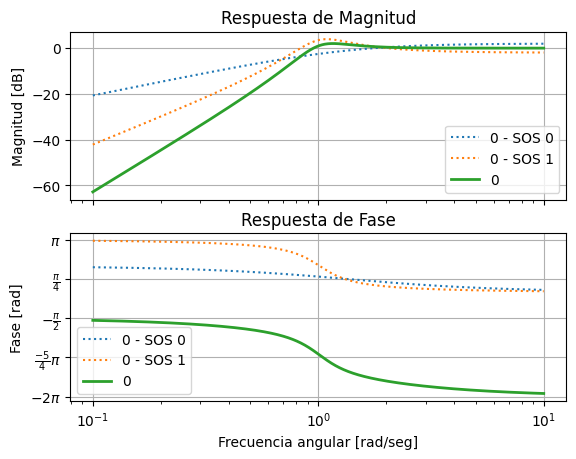

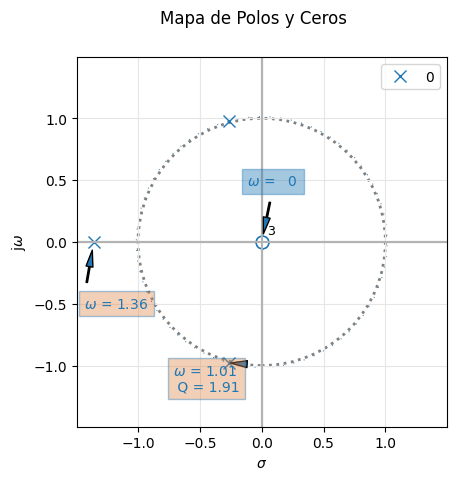

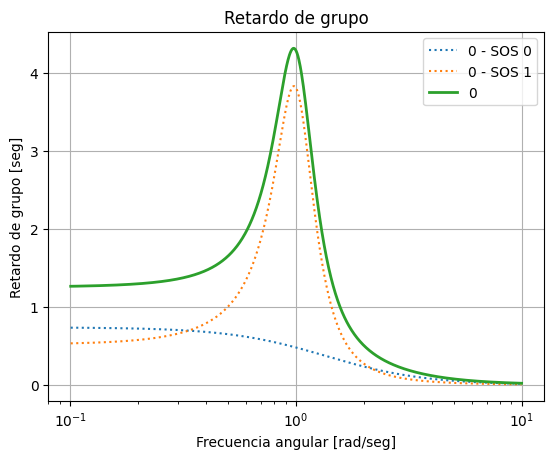

In [4]:
print("numerador:", numHp)
print("denominador:", denHp)
this_sos = tf2sos_analog(numHp, denHp)
pretty_print_SOS(this_sos, mode='omegayq')
analyze_sys(this_sos)

### Bonus 3

Traspaso de circuito sin bobinas segun la tecnica de bruton, la cual se cambia el capacitor por el gic donde la Z2,Z4,Z3 son resistencias y Z1, Z5=capacitores, las bobinas por resistencias y las resistencias por capacitores de modo de "derivar" todos los componentes al multiplicarlos por 1/S 
![FDNR_bruton](FDNR.jpeg) <a id="FDNR"></a>